# 📘 Notebook 6: RLHF — Reinforcement Learning from Human Feedback
## Building LLMs from Scratch Workshop

**Objective:** Implement the complete RLHF pipeline: Reward Modeling → Policy Optimization (PPO).

**This is the most important notebook.** RLHF is what transforms an instruction-following model into an *aligned* model that produces helpful, harmless, and honest outputs.

## The RLHF Pipeline:

```
Step 1: Reward Model Training
   Human annotators rank pairs of model responses
   → Train a reward model to predict human preferences

Step 2: Policy Optimization (PPO)
   Use the reward model as a signal to optimize the language model
   → Add KL penalty to prevent model from diverging too far from SFT model
   → Update policy using PPO (Proximal Policy Optimization)
```

## This Notebook Has 3 Parts:
- **Part A:** Reward Model (train on preference data)
- **Part B:** Policy Model Initialization (load SFT model)
- **Part C:** PPO-Style Training Loop

---


## 1. Setup — All Components

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math, time, json, re, copy
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


In [ ]:
# ============================================================
# Project Directory Setup
# ============================================================
# This cell ensures all paths point to the correct directories
# regardless of where you run the notebook from.
import os

# If running from notebooks/ folder
if os.path.basename(os.getcwd()) == 'notebooks':
    PROJECT_ROOT = os.path.abspath('..')
else:
    PROJECT_ROOT = os.path.abspath('.')

DATA_DIR    = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR  = os.path.join(PROJECT_ROOT, 'models')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')

# Create directories if they don't exist
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Models dir:   {MODELS_DIR}")
print(f"Results dir:  {RESULTS_DIR}")


In [2]:
# ============================================================
# All model components (same as previous notebooks)
# ============================================================
class BPETokenizer:
    def __init__(self, nm=100):
        self.num_merges=nm; self.merges={}; self.vocab={}; self.inverse_vocab={}
        self.special_tokens={'<PAD>':0,'<UNK>':1,'<BOS>':2,'<EOS>':3}
    def _gwf(self, text):
        wf=Counter(re.findall(r'\S+',text.lower()))
        return {tuple(list(w)+['</w>']):f for w,f in wf.items()}
    def _gpc(self, wf):
        p=Counter()
        for wt,f in wf.items():
            for i in range(len(wt)-1): p[(wt[i],wt[i+1])]+=f
        return p
    def _mp(self, wf, pair):
        m=pair[0]+pair[1]; nwf={}
        for wt,f in wf.items():
            nt=[]; i=0
            while i<len(wt):
                if i<len(wt)-1 and wt[i]==pair[0] and wt[i+1]==pair[1]: nt.append(m); i+=2
                else: nt.append(wt[i]); i+=1
            nwf[tuple(nt)]=f
        return nwf
    def train(self, text):
        wf=self._gwf(text); ic=set(t for wt in wf for t in wt)
        for i in range(self.num_merges):
            ps=self._gpc(wf)
            if not ps: break
            bp,c=ps.most_common(1)[0]
            if c<2: break
            self.merges[bp]=bp[0]+bp[1]; wf=self._mp(wf,bp)
        self.vocab=dict(self.special_tokens); idx=len(self.special_tokens)
        for ch in sorted(ic):
            if ch not in self.vocab: self.vocab[ch]=idx; idx+=1
        for p,m in self.merges.items():
            if m not in self.vocab: self.vocab[m]=idx; idx+=1
        self.inverse_vocab={v:k for k,v in self.vocab.items()}
        print(f"Tokenizer: vocab={len(self.vocab)}")
    def _tw(self, word):
        t=list(word)+['</w>']
        for p,m in self.merges.items():
            i=0
            while i<len(t)-1:
                if t[i]==p[0] and t[i+1]==p[1]: t=t[:i]+[m]+t[i+2:]
                else: i+=1
        return t
    def encode(self, text):
        return [self.vocab.get(t,1) for w in re.findall(r'\S+',text.lower()) for t in self._tw(w)]
    def decode(self, ids):
        return ''.join(self.inverse_vocab.get(i,'?') for i in ids).replace('</w>',' ').strip()
    @property
    def vocab_size(self): return len(self.vocab)

class LayerNorm(nn.Module):
    def __init__(self, d, eps=1e-5):
        super().__init__(); self.eps=eps
        self.gamma=nn.Parameter(torch.ones(d)); self.beta=nn.Parameter(torch.zeros(d))
    def forward(self, x):
        return self.gamma*(x-x.mean(-1,keepdim=True))/torch.sqrt(x.var(-1,keepdim=True,unbiased=False)+self.eps)+self.beta

class CausalMHA(nn.Module):
    def __init__(self, cfg):
        super().__init__(); d=cfg['emb_dim']; self.nh=cfg['num_heads']; self.hd=d//self.nh
        self.qkv=nn.Linear(d,3*d,bias=False); self.out=nn.Linear(d,d,bias=False)
        self.ad=nn.Dropout(cfg['drop_rate']); self.rd=nn.Dropout(cfg['drop_rate'])
        self.register_buffer('mask',torch.triu(torch.ones(cfg['context_length'],cfg['context_length']),diagonal=1).bool())
    def forward(self, x):
        B,T,C=x.shape; Q,K,V=self.qkv(x).chunk(3,dim=-1)
        Q=Q.view(B,T,self.nh,self.hd).transpose(1,2); K=K.view(B,T,self.nh,self.hd).transpose(1,2)
        V=V.view(B,T,self.nh,self.hd).transpose(1,2)
        a=Q@K.transpose(-2,-1)/(self.hd**0.5)
        a.masked_fill_(self.mask[:T,:T].unsqueeze(0).unsqueeze(0),float('-inf'))
        return self.rd(self.out((self.ad(F.softmax(a,dim=-1))@V).transpose(1,2).contiguous().view(B,T,C)))

class FFN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(cfg['emb_dim'],cfg['emb_dim']*cfg.get('ff_mult',4)),
            nn.GELU(),nn.Linear(cfg['emb_dim']*cfg.get('ff_mult',4),cfg['emb_dim']),nn.Dropout(cfg['drop_rate']))
    def forward(self, x): return self.net(x)

class TBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1=LayerNorm(cfg['emb_dim']); self.attn=CausalMHA(cfg)
        self.ln2=LayerNorm(cfg['emb_dim']); self.ffn=FFN(cfg)
    def forward(self, x): x=x+self.attn(self.ln1(x)); return x+self.ffn(self.ln2(x))

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__(); self.config=cfg
        self.tok_emb=nn.Embedding(cfg['vocab_size'],cfg['emb_dim'])
        self.pos_emb=nn.Embedding(cfg['context_length'],cfg['emb_dim'])
        self.drop=nn.Dropout(cfg['drop_rate'])
        self.blocks=nn.Sequential(*[TBlock(cfg) for _ in range(cfg['num_layers'])])
        self.final_ln=LayerNorm(cfg['emb_dim'])
        self.lm_head=nn.Linear(cfg['emb_dim'],cfg['vocab_size'],bias=False)
        self.lm_head.weight=self.tok_emb.weight
        self.apply(self._iw)
    def _iw(self, m):
        if isinstance(m,nn.Linear):
            nn.init.normal_(m.weight,std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m,nn.Embedding): nn.init.normal_(m.weight,std=0.02)
    def forward(self, ids, targets=None):
        B,T=ids.shape
        x=self.drop(self.tok_emb(ids)+self.pos_emb(torch.arange(T,device=ids.device)))
        x=self.lm_head(self.final_ln(self.blocks(x)))
        loss=None
        if targets is not None: loss=F.cross_entropy(x.view(-1,x.size(-1)),targets.view(-1))
        return x, loss
    
    def get_hidden_states(self, ids):
        """Get the final hidden states (before lm_head) for reward model."""
        B,T=ids.shape
        x=self.drop(self.tok_emb(ids)+self.pos_emb(torch.arange(T,device=ids.device)))
        x=self.final_ln(self.blocks(x))
        return x  # [B, T, emb_dim]

print("All components loaded!")


All components loaded!


## 2. Prepare Tokenizer and Base Data

In [3]:
# Build tokenizer and corpus
CORPUS = """Machine learning is a subset of artificial intelligence.
Neural networks learn representations from data automatically.
Transformers revolutionized natural language processing.
Attention is all you need was the groundbreaking paper.
Large language models can generate human-like text.
Training requires massive amounts of text data.
Tokenization converts text into numerical sequences.
The embedding layer maps tokens to dense vectors.
Self-attention allows tokens to attend to all others.
Fine-tuning adapts pretrained models to specific tasks.
RLHF uses human preferences to align model outputs.
A reward model scores responses based on preferences.
PPO is a policy optimization algorithm for RLHF.
The KL penalty prevents diverging from the reference.
Temperature controls randomness of text generation.
""" * 10

# Include instruction data
INST_TEXT = " ".join([
    "### instruction: what is machine learning? ### response: machine learning is AI that learns from data.",
    "### instruction: explain attention. ### response: attention lets tokens look at all other tokens.",
    "### instruction: what is RLHF? ### response: RLHF aligns models using human preference feedback.",
] * 10)

tokenizer = BPETokenizer(nm=250)
tokenizer.train(CORPUS + " " + INST_TEXT)

GPT_CONFIG = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": 64,
    "emb_dim": 128,
    "num_heads": 4,
    "num_layers": 4,
    "drop_rate": 0.1,
    "ff_mult": 4,
}
print(f"Config: vocab={GPT_CONFIG['vocab_size']}, emb={GPT_CONFIG['emb_dim']}, layers={GPT_CONFIG['num_layers']}")


Tokenizer: vocab=285
Config: vocab=285, emb=128, layers=4


---
# PART A: Reward Model Training

## 3. Understanding the Reward Model

The reward model learns to predict **human preferences** between pairs of responses.

**Training data format:**
- Given a prompt and two responses (A and B)
- A human annotator chooses which response is better
- The reward model learns to assign higher scores to preferred responses

**Architecture:**
- Takes a GPT backbone (shared with the language model)
- Adds a **value head** that outputs a single scalar score
- Trained using the **Bradley-Terry** preference model:

$$P(\text{response}_A \succ \text{response}_B) = \sigma(r_A - r_B)$$

Where $r_A, r_B$ are the reward scores and $\sigma$ is the sigmoid function.


In [4]:
# ============================================================
# Reward Model Architecture
# ============================================================

class RewardModel(nn.Module):
    """
    Reward Model for RLHF.
    
    Architecture: GPT backbone + value head
    - Uses the GPT model to get hidden states
    - A linear head maps the final hidden state to a scalar reward
    
    The reward is computed from the last token's hidden state
    (similar to how classification models use [CLS] token).
    """
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # GPT backbone (frozen or fine-tuned)
        self.backbone = GPTModel(config)
        
        # Value head: maps hidden state → scalar reward
        self.value_head = nn.Sequential(
            nn.Linear(config['emb_dim'], config['emb_dim'] // 2),
            nn.GELU(),
            nn.Linear(config['emb_dim'] // 2, 1)
        )
        
        # Initialize value head
        for m in self.value_head:
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                nn.init.zeros_(m.bias)
    
    def forward(self, token_ids):
        """
        Compute reward score for a sequence.
        
        Args:
            token_ids: [batch_size, seq_len]
        
        Returns:
            rewards: [batch_size, 1] — scalar reward per sequence
        """
        # Get hidden states from backbone
        hidden = self.backbone.get_hidden_states(token_ids)  # [B, T, D]
        
        # Use the last token's hidden state as the sequence representation
        # (Could also use mean pooling)
        last_hidden = hidden[:, -1, :]  # [B, D]
        
        # Compute reward score
        reward = self.value_head(last_hidden)  # [B, 1]
        
        return reward

# Test reward model
reward_model = RewardModel(GPT_CONFIG).to(device)
test_ids = torch.randint(0, GPT_CONFIG['vocab_size'], (2, 32)).to(device)
test_reward = reward_model(test_ids)
print(f"Input shape:  {test_ids.shape}")
print(f"Reward shape: {test_reward.shape}")
print(f"Rewards: {test_reward.detach().cpu().numpy().flatten()}")
print(f"\nReward model params: {sum(p.numel() for p in reward_model.parameters()):,}")


Input shape:  torch.Size([2, 32])
Reward shape: torch.Size([2, 1])
Rewards: [ 0.0029777  -0.00130383]

Reward model params: 844,289


## 4. Preference Dataset

We create synthetic preference data where we define which responses are "better."
In real RLHF, human annotators provide these preferences.


In [5]:
# ============================================================
# Synthetic Preference Dataset
# ============================================================
# Format: (prompt, chosen_response, rejected_response)
# "Chosen" = what humans prefer; "Rejected" = what humans don't prefer

PREFERENCE_DATA = [
    {
        "prompt": "what is machine learning?",
        "chosen": "machine learning is a subset of artificial intelligence that enables systems to learn and improve from experience without being explicitly programmed. it uses algorithms to find patterns in data.",
        "rejected": "machine learning is something computers do. it is related to technology and stuff about data."
    },
    {
        "prompt": "explain neural networks.",
        "chosen": "a neural network is a computing system inspired by biological brains. it consists of layers of interconnected nodes that process information through weighted connections and activation functions.",
        "rejected": "neural networks are like brains but for computers. they do AI things."
    },
    {
        "prompt": "what is attention in transformers?",
        "chosen": "attention is a mechanism that allows each token in a sequence to compute relevance scores with all other tokens. it uses queries keys and values to create weighted combinations of representations.",
        "rejected": "attention is a way for the model to look at words. it helps with understanding text."
    },
    {
        "prompt": "how does gradient descent work?",
        "chosen": "gradient descent is an optimization algorithm that iteratively updates parameters by computing the gradient of the loss function and moving in the direction that reduces the loss. the learning rate controls the step size.",
        "rejected": "gradient descent makes the model better by changing numbers. it uses math to improve."
    },
    {
        "prompt": "what is RLHF?",
        "chosen": "RLHF stands for reinforcement learning from human feedback. it trains a reward model on human preference data then uses that reward signal to optimize the language model policy using algorithms like PPO.",
        "rejected": "RLHF is a training method that makes AI better. it uses feedback from people."
    },
    {
        "prompt": "explain tokenization.",
        "chosen": "tokenization converts raw text into smaller units called tokens which are then mapped to numerical IDs. methods include byte-pair encoding which iteratively merges frequent character pairs into subword tokens.",
        "rejected": "tokenization splits text into pieces. the model then uses these pieces."
    },
    {
        "prompt": "what is transfer learning?",
        "chosen": "transfer learning is a technique where knowledge gained from training on one task is applied to a different but related task. in NLP pretraining on large corpora then fine-tuning on specific tasks is a powerful form of transfer learning.",
        "rejected": "transfer learning means using a model for different things. it saves time."
    },
    {
        "prompt": "explain cross-entropy loss.",
        "chosen": "cross-entropy loss measures the difference between the predicted probability distribution and the true distribution. for language models it quantifies how well the model predicts the correct next token at each position in the sequence.",
        "rejected": "cross-entropy is a loss function. it tells you how wrong the model is."
    },
]

# Repeat for more training data
PREFERENCE_DATA = PREFERENCE_DATA * 6  # 48 samples

print(f"Total preference pairs: {len(PREFERENCE_DATA)}")
print(f"\nExample:")
print(f"  Prompt:   {PREFERENCE_DATA[0]['prompt']}")
print(f"  Chosen:   {PREFERENCE_DATA[0]['chosen'][:80]}...")
print(f"  Rejected: {PREFERENCE_DATA[0]['rejected'][:80]}...")


Total preference pairs: 48

Example:
  Prompt:   what is machine learning?
  Chosen:   machine learning is a subset of artificial intelligence that enables systems to ...
  Rejected: machine learning is something computers do. it is related to technology and stuf...


In [6]:
class PreferenceDataset(Dataset):
    """
    Dataset for reward model training.
    
    Each item contains tokenized versions of:
    - chosen response (preferred by humans)
    - rejected response (not preferred)
    
    Both are formatted as: "prompt + response"
    """
    
    def __init__(self, data, tokenizer, max_length=64):
        self.samples = []
        pad_id = tokenizer.vocab.get('<PAD>', 0)
        
        for item in data:
            prompt = item['prompt']
            
            # Tokenize chosen and rejected
            chosen_text = f"{prompt} {item['chosen']}"
            rejected_text = f"{prompt} {item['rejected']}"
            
            chosen_ids = tokenizer.encode(chosen_text)[:max_length]
            rejected_ids = tokenizer.encode(rejected_text)[:max_length]
            
            # Pad to max_length
            chosen_ids = chosen_ids + [pad_id] * (max_length - len(chosen_ids))
            rejected_ids = rejected_ids + [pad_id] * (max_length - len(rejected_ids))
            
            self.samples.append({
                'chosen_ids': torch.tensor(chosen_ids[:max_length], dtype=torch.long),
                'rejected_ids': torch.tensor(rejected_ids[:max_length], dtype=torch.long),
            })
        
        print(f"PreferenceDataset: {len(self.samples)} pairs")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        s = self.samples[idx]
        return s['chosen_ids'], s['rejected_ids']

# Create preference dataset
pref_dataset = PreferenceDataset(PREFERENCE_DATA, tokenizer, max_length=GPT_CONFIG['context_length'])
pref_loader = DataLoader(pref_dataset, batch_size=4, shuffle=True, drop_last=True)

c, r = pref_dataset[0]
print(f"Chosen shape:   {c.shape}")
print(f"Rejected shape: {r.shape}")


PreferenceDataset: 48 pairs
Chosen shape:   torch.Size([64])
Rejected shape: torch.Size([64])


## 5. Training the Reward Model

**Loss function:** Bradley-Terry model

$$\mathcal{L} = -\log \sigma(r_{\text{chosen}} - r_{\text{rejected}})$$

This pushes the reward model to assign higher scores to chosen (preferred) responses.


In [7]:
# ============================================================
# Reward Model Training
# ============================================================

reward_model = RewardModel(GPT_CONFIG).to(device)
rm_optimizer = torch.optim.AdamW(reward_model.parameters(), lr=1e-4, weight_decay=0.01)

NUM_RM_EPOCHS = 20
rm_losses = []
rm_accuracies = []

print("=" * 60)
print("TRAINING REWARD MODEL")
print("=" * 60)

for epoch in range(NUM_RM_EPOCHS):
    reward_model.train()
    epoch_loss = 0
    epoch_correct = 0
    epoch_total = 0
    
    for chosen_ids, rejected_ids in pref_loader:
        chosen_ids = chosen_ids.to(device)
        rejected_ids = rejected_ids.to(device)
        
        # Get rewards for both responses
        reward_chosen = reward_model(chosen_ids)      # [B, 1]
        reward_rejected = reward_model(rejected_ids)   # [B, 1]
        
        # Bradley-Terry loss: -log(sigma(r_chosen - r_rejected))
        # This is equivalent to binary cross-entropy with labels=1
        loss = -F.logsigmoid(reward_chosen - reward_rejected).mean()
        
        # Backward pass
        rm_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(reward_model.parameters(), 1.0)
        rm_optimizer.step()
        
        epoch_loss += loss.item()
        
        # Compute accuracy: how often does the model rank chosen > rejected?
        with torch.no_grad():
            correct = (reward_chosen > reward_rejected).float().sum().item()
            epoch_correct += correct
            epoch_total += chosen_ids.size(0)
    
    avg_loss = epoch_loss / len(pref_loader)
    accuracy = epoch_correct / max(epoch_total, 1) * 100
    rm_losses.append(avg_loss)
    rm_accuracies.append(accuracy)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{NUM_RM_EPOCHS} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.1f}%")

print(f"\nFinal RM accuracy: {rm_accuracies[-1]:.1f}%")


TRAINING REWARD MODEL
Epoch  5/20 | Loss: 0.2438 | Accuracy: 100.0%
Epoch 10/20 | Loss: 0.0539 | Accuracy: 100.0%
Epoch 15/20 | Loss: 0.0160 | Accuracy: 100.0%
Epoch 20/20 | Loss: 0.0078 | Accuracy: 100.0%

Final RM accuracy: 100.0%


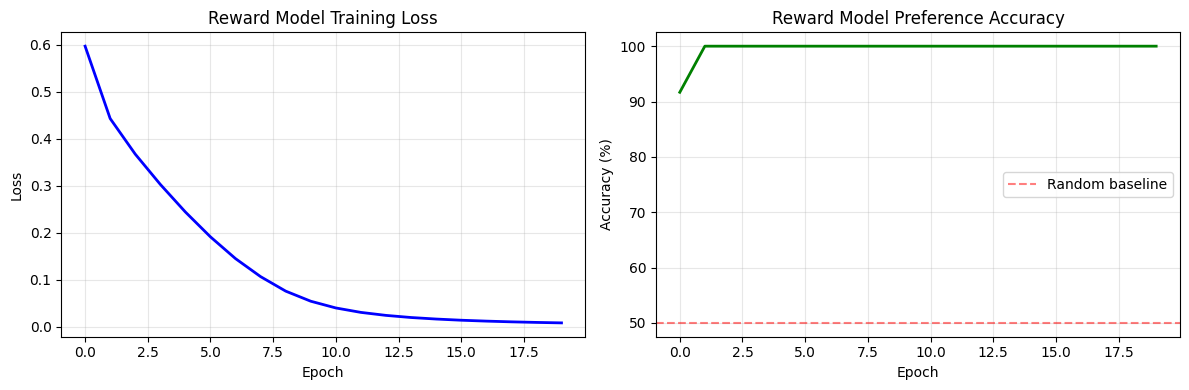

Accuracy > 50% means the model is better than random at predicting preferences!


In [8]:
# Plot reward model training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(rm_losses, 'b-', linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Reward Model Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(rm_accuracies, 'g-', linewidth=2)
ax2.axhline(y=50, color='r', linestyle='--', alpha=0.5, label='Random baseline')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Reward Model Preference Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reward_model_training.png', dpi=100)
plt.show()
print("Accuracy > 50% means the model is better than random at predicting preferences!")


In [9]:
# Test the reward model
print("\n" + "=" * 60)
print("REWARD MODEL SCORING TEST")
print("=" * 60)

reward_model.eval()
with torch.no_grad():
    for item in PREFERENCE_DATA[:4]:
        prompt = item['prompt']
        chosen_text = f"{prompt} {item['chosen']}"
        rejected_text = f"{prompt} {item['rejected']}"
        
        chosen_ids = tokenizer.encode(chosen_text)[:GPT_CONFIG['context_length']]
        rejected_ids = tokenizer.encode(rejected_text)[:GPT_CONFIG['context_length']]
        
        pad_id = 0
        chosen_ids += [pad_id] * (GPT_CONFIG['context_length'] - len(chosen_ids))
        rejected_ids += [pad_id] * (GPT_CONFIG['context_length'] - len(rejected_ids))
        
        r_chosen = reward_model(torch.tensor([chosen_ids]).to(device)).item()
        r_rejected = reward_model(torch.tensor([rejected_ids]).to(device)).item()
        
        winner = "CHOSEN ✓" if r_chosen > r_rejected else "REJECTED ✗"
        print(f"\nPrompt: {prompt}")
        print(f"  Chosen reward:   {r_chosen:.4f}")
        print(f"  Rejected reward: {r_rejected:.4f}")
        print(f"  Winner: {winner}")



REWARD MODEL SCORING TEST

Prompt: what is machine learning?
  Chosen reward:   2.4801
  Rejected reward: -2.5083
  Winner: CHOSEN ✓

Prompt: explain neural networks.
  Chosen reward:   2.4801
  Rejected reward: -2.5086
  Winner: CHOSEN ✓

Prompt: what is attention in transformers?
  Chosen reward:   2.4801
  Rejected reward: -2.5081
  Winner: CHOSEN ✓

Prompt: how does gradient descent work?
  Chosen reward:   2.4799
  Rejected reward: -2.5042
  Winner: CHOSEN ✓


---
# PART B: Policy Model Initialization

## 6. Setting Up the Policy and Reference Models

For PPO, we need:
1. **Policy model** — the model we're optimizing (starts from SFT weights)
2. **Reference model** — a frozen copy of the SFT model (for KL penalty)
3. **Reward model** — already trained above

The **KL divergence penalty** prevents the policy from diverging too far from the reference:
$$\text{reward}_{\text{final}} = r_{\text{RM}}(x) - \beta \cdot \text{KL}(\pi_{\text{policy}} \| \pi_{\text{ref}})$$


In [10]:
# ============================================================
# Initialize Policy and Reference Models
# ============================================================

# Policy model (will be updated by PPO)
policy_model = GPTModel(GPT_CONFIG).to(device)

# Reference model (frozen — stays at SFT weights)
ref_model = GPTModel(GPT_CONFIG).to(device)

# Copy weights from policy to reference
ref_model.load_state_dict(policy_model.state_dict())

# FREEZE the reference model — this is critical!
for param in ref_model.parameters():
    param.requires_grad = False
ref_model.eval()

# Freeze the reward model too
for param in reward_model.parameters():
    param.requires_grad = False
reward_model.eval()

policy_params = sum(p.numel() for p in policy_model.parameters() if p.requires_grad)
ref_params = sum(p.numel() for p in ref_model.parameters() if p.requires_grad)
rm_params = sum(p.numel() for p in reward_model.parameters() if p.requires_grad)

print(f"Policy model trainable params: {policy_params:,}")
print(f"Reference model trainable params: {ref_params:,} (frozen!)")
print(f"Reward model trainable params: {rm_params:,} (frozen!)")


Policy model trainable params: 835,968
Reference model trainable params: 0 (frozen!)
Reward model trainable params: 0 (frozen!)


---
# PART C: PPO-Style Training

## 7. Understanding PPO for RLHF

### The PPO Objective:

$$\mathcal{L}^{\text{PPO}} = \hat{\mathbb{E}}_t \left[ \min\left( r_t(\theta) \hat{A}_t, \; \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon) \hat{A}_t \right) \right]$$

Where:
- $r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\text{old}}(a_t|s_t)}$ is the probability ratio
- $\hat{A}_t$ is the advantage estimate
- $\epsilon$ is the clipping parameter (typically 0.2)

### Our Simplified RLHF-PPO Loop:

```
For each batch of prompts:
    1. Generate responses using the policy model
    2. Score responses with the reward model
    3. Compute KL penalty between policy and reference
    4. Compute advantages (reward - KL penalty)
    5. Update policy using PPO clipping
```


In [11]:
# ============================================================
# PPO Helper Functions
# ============================================================

def compute_log_probs(model, input_ids, output_ids):
    """
    Compute log probabilities of output_ids under the model.
    
    Args:
        model: Language model
        input_ids: [B, T] prompt + response tokens
        output_ids: [B, T] target tokens (shifted input)
    
    Returns:
        log_probs: [B, T] per-token log probabilities
    """
    with torch.no_grad() if not model.training else torch.enable_grad():
        logits, _ = model(input_ids)  # [B, T, V]
        log_probs = F.log_softmax(logits, dim=-1)  # [B, T, V]
        
        # Gather log probs for the actual tokens
        # output_ids: [B, T] → [B, T, 1]
        token_log_probs = log_probs.gather(2, output_ids.unsqueeze(-1)).squeeze(-1)
        
        return token_log_probs  # [B, T]


def compute_kl_divergence(policy_log_probs, ref_log_probs):
    """
    Compute KL divergence between policy and reference per token.
    
    KL(policy || ref) ≈ exp(policy_log_prob) * (policy_log_prob - ref_log_prob)
    Simplified: policy_log_prob - ref_log_prob (since we're comparing the same tokens)
    """
    return policy_log_probs - ref_log_probs  # Approximate KL per token


@torch.no_grad()
def generate_responses(model, prompts_ids, max_new_tokens=20, temperature=0.8, top_k=20):
    """
    Generate responses from prompts.
    
    Args:
        model: Policy model
        prompts_ids: [B, prompt_len] tokenized prompts
        max_new_tokens: Number of tokens to generate
    
    Returns:
        full_ids: [B, prompt_len + max_new_tokens] full sequences
        response_ids: [B, max_new_tokens] just the generated part
    """
    model.eval()
    B = prompts_ids.shape[0]
    ctx = model.config['context_length']
    generated = prompts_ids.clone()
    
    for _ in range(max_new_tokens):
        idx = generated[:, -ctx:]
        logits, _ = model(idx)
        logits = logits[:, -1, :] / max(temperature, 1e-8)
        
        if top_k:
            tv, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < tv[:, -1:]] = float('-inf')
        
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, 1)
        generated = torch.cat([generated, next_token], dim=1)
    
    response_ids = generated[:, prompts_ids.shape[1]:]
    return generated, response_ids


def get_reward_score(reward_model, full_sequence_ids, max_len=64):
    """Get reward scores for full sequences."""
    # Truncate/pad to max_len
    B = full_sequence_ids.shape[0]
    pad_id = 0
    
    if full_sequence_ids.shape[1] > max_len:
        ids = full_sequence_ids[:, :max_len]
    else:
        pad_len = max_len - full_sequence_ids.shape[1]
        ids = F.pad(full_sequence_ids, (0, pad_len), value=pad_id)
    
    with torch.no_grad():
        rewards = reward_model(ids)  # [B, 1]
    
    return rewards.squeeze(-1)  # [B]

print("PPO helper functions defined!")


PPO helper functions defined!


## 8. PPO Training Loop

This is the core of RLHF. For each batch:
1. Generate responses from the policy
2. Score them with the reward model
3. Compute the KL penalty
4. Compute the clipped surrogate objective
5. Update the policy


In [12]:
# ============================================================
# PPO PROMPTS
# ============================================================
PPO_PROMPTS = [
    "what is machine learning?",
    "explain neural networks.",
    "what is attention?",
    "how does gradient descent work?",
    "what is RLHF?",
    "explain tokenization.",
    "what is transfer learning?",
    "explain cross-entropy loss.",
    "what is a transformer?",
    "how does text generation work?",
    "what is perplexity?",
    "explain dropout regularization.",
]

# Tokenize prompts
prompt_prefix = "### instruction: "
response_prefix = " ### response: "

tokenized_prompts = []
for p in PPO_PROMPTS:
    ids = tokenizer.encode(prompt_prefix + p + response_prefix)
    tokenized_prompts.append(ids)

# Pad prompts to same length
max_prompt_len = max(len(p) for p in tokenized_prompts)
max_prompt_len = min(max_prompt_len, GPT_CONFIG['context_length'] // 2)

padded_prompts = []
for ids in tokenized_prompts:
    ids = ids[:max_prompt_len]
    ids = ids + [0] * (max_prompt_len - len(ids))
    padded_prompts.append(ids)

prompt_tensor = torch.tensor(padded_prompts, dtype=torch.long).to(device)
print(f"Number of prompts: {len(PPO_PROMPTS)}")
print(f"Prompt tensor shape: {prompt_tensor.shape}")


Number of prompts: 12
Prompt tensor shape: torch.Size([12, 29])


In [13]:
# ============================================================
# PPO TRAINING LOOP
# ============================================================

# PPO Hyperparameters
PPO_EPOCHS = 30           # Number of PPO iterations
PPO_BATCH_SIZE = 4        # Prompts per batch
PPO_INNER_EPOCHS = 2      # Inner PPO updates per batch
MAX_NEW_TOKENS = 15       # Tokens to generate per response
KL_COEFF = 0.1            # KL penalty coefficient (β)
CLIP_EPSILON = 0.2        # PPO clipping parameter
PPO_LR = 5e-5             # Learning rate for policy updates
GAMMA = 1.0               # Discount factor (1.0 for single-step rewards)
TEMPERATURE = 0.8

# Optimizer for the policy model only
ppo_optimizer = torch.optim.AdamW(policy_model.parameters(), lr=PPO_LR, weight_decay=0.01)

# Tracking
ppo_rewards = []
ppo_kl_divs = []
ppo_losses = []
ppo_ref_rewards = []

print("=" * 60)
print("STARTING PPO TRAINING")
print("=" * 60)
print(f"Epochs: {PPO_EPOCHS}, KL coeff: {KL_COEFF}, Clip: {CLIP_EPSILON}")
print(f"Max new tokens: {MAX_NEW_TOKENS}, LR: {PPO_LR}")
print("=" * 60)

start_time = time.time()

for epoch in range(PPO_EPOCHS):
    epoch_reward = 0
    epoch_kl = 0
    epoch_loss = 0
    num_batches = 0
    
    # Shuffle prompts
    perm = torch.randperm(prompt_tensor.size(0))
    
    for batch_start in range(0, len(perm), PPO_BATCH_SIZE):
        batch_idx = perm[batch_start:batch_start + PPO_BATCH_SIZE]
        if len(batch_idx) < 2:
            continue
        
        batch_prompts = prompt_tensor[batch_idx]
        
        # ---- Step 1: Generate responses ----
        policy_model.eval()
        full_sequences, response_tokens = generate_responses(
            policy_model, batch_prompts, 
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE, top_k=20
        )
        
        # Truncate to context_length
        max_ctx = GPT_CONFIG['context_length']
        if full_sequences.shape[1] > max_ctx:
            full_sequences = full_sequences[:, :max_ctx]
        
        # ---- Step 2: Score with reward model ----
        rewards = get_reward_score(reward_model, full_sequences, max_len=max_ctx)
        
        # ---- Step 3: Compute log probs and KL ----
        # We need the input tokens and target tokens
        input_tokens = full_sequences[:, :-1]
        target_tokens = full_sequences[:, 1:]
        
        # Make sure we're within context length
        if input_tokens.shape[1] > max_ctx:
            input_tokens = input_tokens[:, :max_ctx]
            target_tokens = target_tokens[:, :max_ctx]
        
        # Log probs from policy (old — before update)
        policy_model.eval()
        with torch.no_grad():
            old_log_probs = compute_log_probs(policy_model, input_tokens, target_tokens)
        
        # Log probs from reference
        ref_log_probs = compute_log_probs(ref_model, input_tokens, target_tokens)
        
        # KL divergence per token
        kl_per_token = compute_kl_divergence(old_log_probs, ref_log_probs)
        avg_kl = kl_per_token.mean(dim=-1)  # [B] — average KL per sequence
        
        # ---- Step 4: Compute advantages ----
        # advantage = reward - KL_penalty
        kl_penalty = KL_COEFF * avg_kl
        advantages = rewards - kl_penalty
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)  # Normalize
        
        # ---- Step 5: PPO update ----
        policy_model.train()
        
        for inner_epoch in range(PPO_INNER_EPOCHS):
            # Current log probs
            current_log_probs = compute_log_probs(policy_model, input_tokens, target_tokens)
            
            # Sum log probs over response tokens (sequence-level)
            # Focus on response portion only
            prompt_len = batch_prompts.shape[1]
            if prompt_len < current_log_probs.shape[1]:
                response_current_lp = current_log_probs[:, prompt_len-1:].sum(dim=-1)
                response_old_lp = old_log_probs[:, prompt_len-1:].sum(dim=-1)
            else:
                response_current_lp = current_log_probs.sum(dim=-1)
                response_old_lp = old_log_probs.sum(dim=-1)
            
            # Probability ratio
            ratio = torch.exp(response_current_lp - response_old_lp)
            
            # PPO clipped objective
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1 - CLIP_EPSILON, 1 + CLIP_EPSILON) * advantages
            ppo_loss = -torch.min(surr1, surr2).mean()
            
            # Add entropy bonus for exploration
            entropy = -(torch.exp(current_log_probs) * current_log_probs).sum(dim=-1).mean()
            total_loss = ppo_loss - 0.01 * entropy
            
            ppo_optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(policy_model.parameters(), 1.0)
            ppo_optimizer.step()
        
        epoch_reward += rewards.mean().item()
        epoch_kl += avg_kl.mean().item()
        epoch_loss += ppo_loss.item()
        num_batches += 1
    
    # Track metrics
    if num_batches > 0:
        avg_reward = epoch_reward / num_batches
        avg_kl_val = epoch_kl / num_batches
        avg_loss = epoch_loss / num_batches
    else:
        avg_reward = avg_kl_val = avg_loss = 0
    
    ppo_rewards.append(avg_reward)
    ppo_kl_divs.append(avg_kl_val)
    ppo_losses.append(avg_loss)
    
    if (epoch + 1) % 5 == 0:
        elapsed = time.time() - start_time
        print(f"PPO Epoch {epoch+1:3d} | Reward: {avg_reward:+.4f} | "
              f"KL: {avg_kl_val:.4f} | Loss: {avg_loss:.4f} | Time: {elapsed:.0f}s")

total_time = time.time() - start_time
print(f"\nPPO training complete! Time: {total_time:.0f}s")


STARTING PPO TRAINING
Epochs: 30, KL coeff: 0.1, Clip: 0.2
Max new tokens: 15, LR: 5e-05
PPO Epoch   5 | Reward: -2.4640 | KL: 0.2053 | Loss: 0.0319 | Time: 3s
PPO Epoch  10 | Reward: -2.4621 | KL: 0.3657 | Loss: -0.0240 | Time: 7s
PPO Epoch  15 | Reward: -2.4614 | KL: 0.4697 | Loss: 0.0141 | Time: 10s
PPO Epoch  20 | Reward: -2.4588 | KL: 0.5200 | Loss: 0.0937 | Time: 13s
PPO Epoch  25 | Reward: -2.4612 | KL: 0.4980 | Loss: -0.0169 | Time: 16s
PPO Epoch  30 | Reward: -2.4605 | KL: 0.6576 | Loss: 0.0141 | Time: 20s

PPO training complete! Time: 20s


## 9. PPO Training Analysis

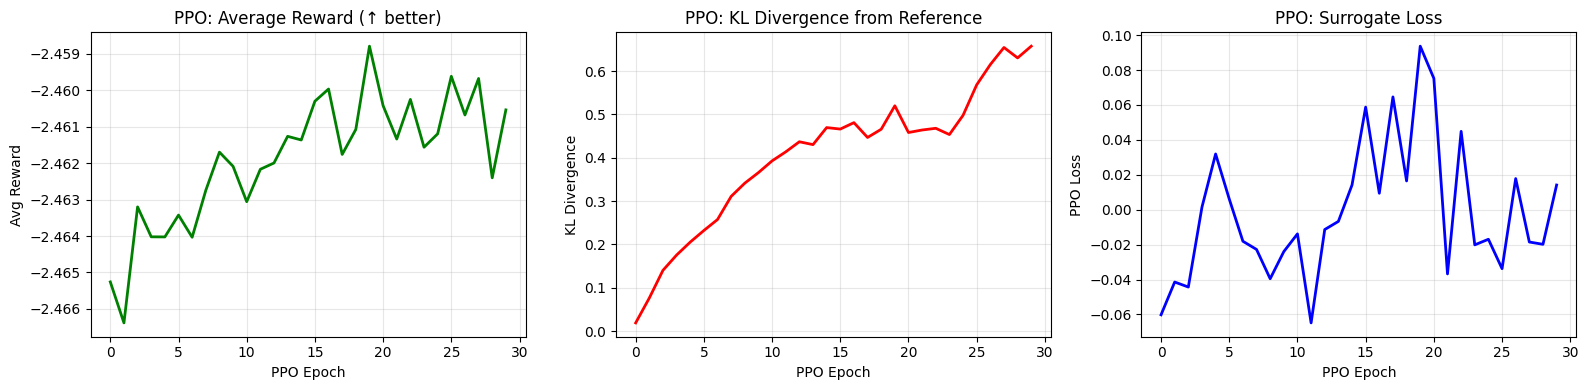

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Rewards
axes[0].plot(ppo_rewards, 'g-', linewidth=2)
axes[0].set_xlabel('PPO Epoch'); axes[0].set_ylabel('Avg Reward')
axes[0].set_title('PPO: Average Reward (↑ better)')
axes[0].grid(True, alpha=0.3)

# KL divergence
axes[1].plot(ppo_kl_divs, 'r-', linewidth=2)
axes[1].set_xlabel('PPO Epoch'); axes[1].set_ylabel('KL Divergence')
axes[1].set_title('PPO: KL Divergence from Reference')
axes[1].grid(True, alpha=0.3)

# Loss
axes[2].plot(ppo_losses, 'b-', linewidth=2)
axes[2].set_xlabel('PPO Epoch'); axes[2].set_ylabel('PPO Loss')
axes[2].set_title('PPO: Surrogate Loss')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ppo_training.png', dpi=100)
plt.show()


## 10. Comparing Reference (SFT) vs. RLHF Model

In [15]:
@torch.no_grad()
def gen(model, prompt, tokenizer, max_new=30, temp=0.7, top_k=15, device='cpu'):
    model.eval()
    ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long).to(device)
    ctx = model.config['context_length']
    for _ in range(max_new):
        idx = ids[:, -ctx:]
        logits, _ = model(idx)
        logits = logits[:, -1, :] / max(temp, 1e-8)
        if top_k:
            tv, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < tv[:, -1:]] = float('-inf')
        probs = F.softmax(logits, dim=-1)
        nxt = torch.multinomial(probs, 1) if temp > 0 else torch.argmax(probs, -1, keepdim=True)
        ids = torch.cat([ids, nxt], 1)
    return tokenizer.decode(ids[0].tolist())

print("=" * 70)
print("REFERENCE (SFT) vs RLHF-PPO MODEL COMPARISON")
print("=" * 70)

test_prompts = [
    "### instruction: what is machine learning? ### response:",
    "### instruction: explain attention mechanism. ### response:",
    "### instruction: what is RLHF? ### response:",
]

for prompt in test_prompts:
    q = prompt.split("### response:")[0].replace("### instruction:", "Q:").strip()
    print(f"\n{'─' * 60}")
    print(f"{q}")
    print(f"{'─' * 60}")
    
    ref_out = gen(ref_model, prompt, tokenizer, device=device)
    ref_resp = ref_out.split("### response:")[-1].strip() if "### response:" in ref_out else ref_out
    print(f"  REF:  {ref_resp[:100]}")
    
    ppo_out = gen(policy_model, prompt, tokenizer, device=device)
    ppo_resp = ppo_out.split("### response:")[-1].strip() if "### response:" in ppo_out else ppo_out
    print(f"  RLHF: {ppo_resp[:100]}")
    
    # Score both with reward model
    ref_ids = tokenizer.encode(ref_out)[:GPT_CONFIG['context_length']]
    ppo_ids = tokenizer.encode(ppo_out)[:GPT_CONFIG['context_length']]
    ref_ids += [0] * (GPT_CONFIG['context_length'] - len(ref_ids))
    ppo_ids += [0] * (GPT_CONFIG['context_length'] - len(ppo_ids))
    
    r_ref = reward_model(torch.tensor([ref_ids]).to(device)).item()
    r_ppo = reward_model(torch.tensor([ppo_ids]).to(device)).item()
    print(f"  Rewards: REF={r_ref:.3f}, RLHF={r_ppo:.3f} {'← RLHF wins!' if r_ppo > r_ref else ''}")


REFERENCE (SFT) vs RLHF-PPO MODEL COMPARISON

────────────────────────────────────────────────────────────
Q: what is machine learning?
────────────────────────────────────────────────────────────
  REF:  y##machine whbonemachine uunetworkuuxy from oramoed ??leighuman-lrepresentations tokenization <UNK><
  RLHF: <EOS>a ha lang-y a a machxxmodeha procexmachine modefrom from from -hfrom modea y -a
  Rewards: REF=-2.493, RLHF=-2.497 

────────────────────────────────────────────────────────────
Q: explain attention mechanism.
────────────────────────────────────────────────────────────
  REF:  large requiqtext. lesequsequ<BOS><BOS>large iqtextconvnetwizationattentionizationto .insinstructionr
  RLHF: machmodevxvxhgroundbreamachxlangy y y hxmodemodemachy <EOS>machine y machhmachine y procexconver
  Rewards: REF=-2.480, RLHF=-2.507 

────────────────────────────────────────────────────────────
Q: what is RLHF?
────────────────────────────────────────────────────────────
  REF:  transformers

## 11. Save All Models

In [16]:
# Save the RLHF-trained policy model
torch.save({
    'policy_state_dict': policy_model.state_dict(),
    'ref_state_dict': ref_model.state_dict(),
    'reward_state_dict': reward_model.state_dict(),
    'config': GPT_CONFIG,
    'tokenizer_vocab': tokenizer.vocab,
    'tokenizer_merges': {f"{k[0]}|||{k[1]}": v for k, v in tokenizer.merges.items()},
    'tokenizer_special_tokens': tokenizer.special_tokens,
    'tokenizer_num_merges': tokenizer.num_merges,
    'ppo_rewards': ppo_rewards,
    'ppo_kl_divs': ppo_kl_divs,
}, 'rlhf_models.pt')
print("All RLHF models saved to rlhf_models.pt")
print("Ready for Notebook 7: Final Chat Model!")


All RLHF models saved to rlhf_models.pt
Ready for Notebook 7: Final Chat Model!


## 12. Exercises & Summary

### Exercise 1: KL Coefficient Sweep
Train with KL_COEFF in {0.01, 0.1, 0.5, 1.0}. How does it affect reward vs. generation quality?

### Exercise 2: Reward Hacking
What happens if you train PPO for too many epochs? Does the model "hack" the reward model?

### Exercise 3: DPO Alternative
Implement Direct Preference Optimization (DPO) — a simpler alternative to PPO:
$$\mathcal{L}_{DPO} = -\log \sigma\left(\beta \log \frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \beta \log \frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}\right)$$

---

## 🎯 Interview Questions

1. **What is reward hacking?** — When the policy learns to exploit weaknesses in the reward model to get high rewards without actually producing good outputs. The KL penalty mitigates this.

2. **Why is the KL penalty needed?** — Without it, the policy could diverge far from the reference model, producing degenerate text that scores high with the reward model but is nonsensical.

3. **What is the PPO clipping for?** — It prevents too-large policy updates in a single step, stabilizing training. The ratio is clipped to [1-ε, 1+ε].

4. **Why use a separate reference model?** — The reference model provides a stable baseline for computing KL divergence. If we used the updating policy as reference, the penalty would always be zero.

5. **Why Bradley-Terry for the reward model?** — It provides a principled probabilistic framework for learning from pairwise comparisons, which is the format human feedback naturally comes in.

---

## ✅ Summary

1. ✅ **Part A:** Built and trained a Reward Model on preference data
2. ✅ **Part B:** Initialized policy (trainable) and reference (frozen) models
3. ✅ **Part C:** Implemented full PPO training loop with KL penalty
4. ✅ Compared reference vs. RLHF model outputs
5. ✅ Visualized reward, KL, and loss curves

**Next: Notebook 7 — Final Chat Model →**
